# 🏥 VitaCure Healthcare Private Limited
## Healthcare Operations Analytics — Internship Project
**Analyst:** A. Shanthan Kumar | **Internship Period:** July 2024 – September 2024  
**Company:** VitaCure Healthcare Private Limited  
**Tools Used:** Python (Pandas, Matplotlib, Seaborn), Power BI

---

### 📌 Project Objective
VitaCure is an early-stage physiotherapy startup operating across multiple Indian cities. As a Data Analyst Intern, I was tasked with:
1. Analyzing session-level operational data to understand revenue performance
2. Identifying root causes of cancellations and revenue leakage
3. Profiling therapist performance to support staffing decisions
4. Delivering an executive Power BI dashboard for ongoing monitoring

---


## 1. Environment Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

BRAND_COLOR = "#1A6B8A"   # VitaCure teal
ACCENT      = "#E05A2B"   # warning / leakage color

df = pd.read_csv("vitacure_dataset.csv", parse_dates=["Date"])
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (1200, 16)


,Session_ID,Patient_ID,Date,Day_of_Week,Hour,Therapist,Therapist_Experience_Years,Condition,Session_Type,City,Payment_Mode,Session_Duration_mins,Cancelled,Cancellation_Reason,Realized_Revenue,Revenue_Leakage
0,SES0420,PT0123,2024-07-01,Monday,19,Dr. Priya Sharma,8,Post-Stroke Recovery,Home Visit,Bangalore,Insurance,0,1,Rescheduled,0,2640
1,SES1118,PT0257,2024-07-01,Monday,14,Dr. Kavitha Reddy,6,Shoulder Injury,Home Visit,Bangalore,UPI,60,0,NaN,1841,0
2,SES0813,PT0252,2024-07-01,Monday,10,Dr. Arjun Nair,3,Arthritis,Home Visit,Pune,UPI,60,0,NaN,1574,0
3,SES0710,PT0153,2024-07-02,Tuesday,13,Dr. Priya Sharma,8,Lower Back Pain,Home Visit,Hyderabad,Card,90,0,NaN,1592,0
4,SES0673,PT0299,2024-07-02,Tuesday,14,Dr. Kavitha Reddy,6,Sports Injury,In-Clinic,Pune,Insurance,30,0,NaN,1770,0


## 2. Data Overview & Quality Check

In [2]:
print("=== Column Info ===")
df.info()
print()
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0])
print()
print("=== Descriptive Statistics (Numeric) ===")
df.describe().round(2)


=== Column Info ===
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Session_ID                  1200 non-null   str           
 1   Patient_ID                  1200 non-null   str           
 2   Date                        1200 non-null   datetime64[us]
 3   Day_of_Week                 1200 non-null   str           
 4   Hour                        1200 non-null   int64         
 5   Therapist                   1200 non-null   str           
 6   Therapist_Experience_Years  1200 non-null   int64         
 7   Condition                   1200 non-null   str           
 8   Session_Type                1200 non-null   str           
 9   City                        1200 non-null   str           
 10  Payment_Mode                1200 non-null   str           
 11  Session_Duration_mins       1200 non-null   int

,Date,Hour,Therapist_Experience_Years,Session_Duration_mins,Cancelled,Realized_Revenue,Revenue_Leakage
count,1200,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,2024-09-30 11:32:24,13.70,7.42,43.08,0.22,1219.95,345.06
min,2024-07-01 00:00:00,9.00,2.00,0.00,0.00,0.00,0.00
25%,2024-08-15 00:00:00,11.00,3.00,30.00,0.00,1028.00,0.00
50%,2024-10-01 00:00:00,14.00,6.00,45.00,0.00,1376.50,0.00
75%,2024-11-15 00:00:00,16.00,11.00,60.00,0.00,1699.25,0.00
max,2024-12-31 00:00:00,19.00,15.00,90.00,1.00,2746.00,2640.00
std,NaN,2.77,4.53,26.03,0.41,727.09,679.59


In [3]:
# Note: Cancellation_Reason is null for non-cancelled sessions — expected
print("Unique values per categorical column:")
for col in ['Therapist','Condition','Session_Type','City','Payment_Mode','Day_of_Week','Cancellation_Reason']:
    print(f"  {col}: {df[col].nunique()} unique → {df[col].dropna().unique().tolist()}")


Unique values per categorical column:
  Therapist: 6 unique → ['Dr. Priya Sharma', 'Dr. Kavitha Reddy', 'Dr. Arjun Nair', 'Dr. Rohan Verma', 'Dr. Suresh Pillai', 'Dr. Meena Iyer']
  Condition: 8 unique → ['Post-Stroke Recovery', 'Shoulder Injury', 'Arthritis', 'Lower Back Pain', 'Sports Injury', 'Fracture Recovery', 'Cervical Spondylosis', 'Knee Rehabilitation']
  Session_Type: 3 unique → ['Home Visit', 'In-Clinic', 'Teleconsultation']
  City: 5 unique → ['Bangalore', 'Pune', 'Hyderabad', 'Mumbai', 'Chennai']
  Payment_Mode: 4 unique → ['Insurance', 'UPI', 'Card', 'Cash']
  Day_of_Week: 6 unique → ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
  Cancellation_Reason: 5 unique → ['Rescheduled', 'Doctor Unavailable', 'Patient Emergency', 'No Show', 'Last-Minute Cancel']


## 3. Key Business KPIs

In [4]:
total_sessions      = len(df)
total_revenue       = df['Realized_Revenue'].sum()
total_leakage       = df['Revenue_Leakage'].sum()
cancellation_rate   = df['Cancelled'].mean() * 100
avg_session_value   = df[df['Cancelled']==0]['Realized_Revenue'].mean()
unique_patients     = df['Patient_ID'].nunique()
returning_patients  = df.groupby('Patient_ID').size()
retention_rate      = (returning_patients[returning_patients > 1].count() / unique_patients) * 100

print("=" * 50)
print(f"  Total Sessions         : {total_sessions:,}")
print(f"  Unique Patients        : {unique_patients:,}")
print(f"  Patient Retention Rate : {retention_rate:.1f}%")
print(f"  Cancellation Rate      : {cancellation_rate:.1f}%")
print(f"  Total Realized Revenue : ₹{total_revenue:,.0f}")
print(f"  Total Revenue Leakage  : ₹{total_leakage:,.0f}")
print(f"  Leakage as % of Revenue: {total_leakage/(total_revenue+total_leakage)*100:.1f}%")
print(f"  Avg Session Value      : ₹{avg_session_value:,.0f}")
print("=" * 50)


  Total Sessions         : 1,200
  Unique Patients        : 371
  Patient Retention Rate : 84.1%
  Cancellation Rate      : 21.8%
  Total Realized Revenue : ₹1,463,936
  Total Revenue Leakage  : ₹414,067
  Leakage as % of Revenue: 22.0%
  Avg Session Value      : ₹1,559


## 4. Revenue Analysis

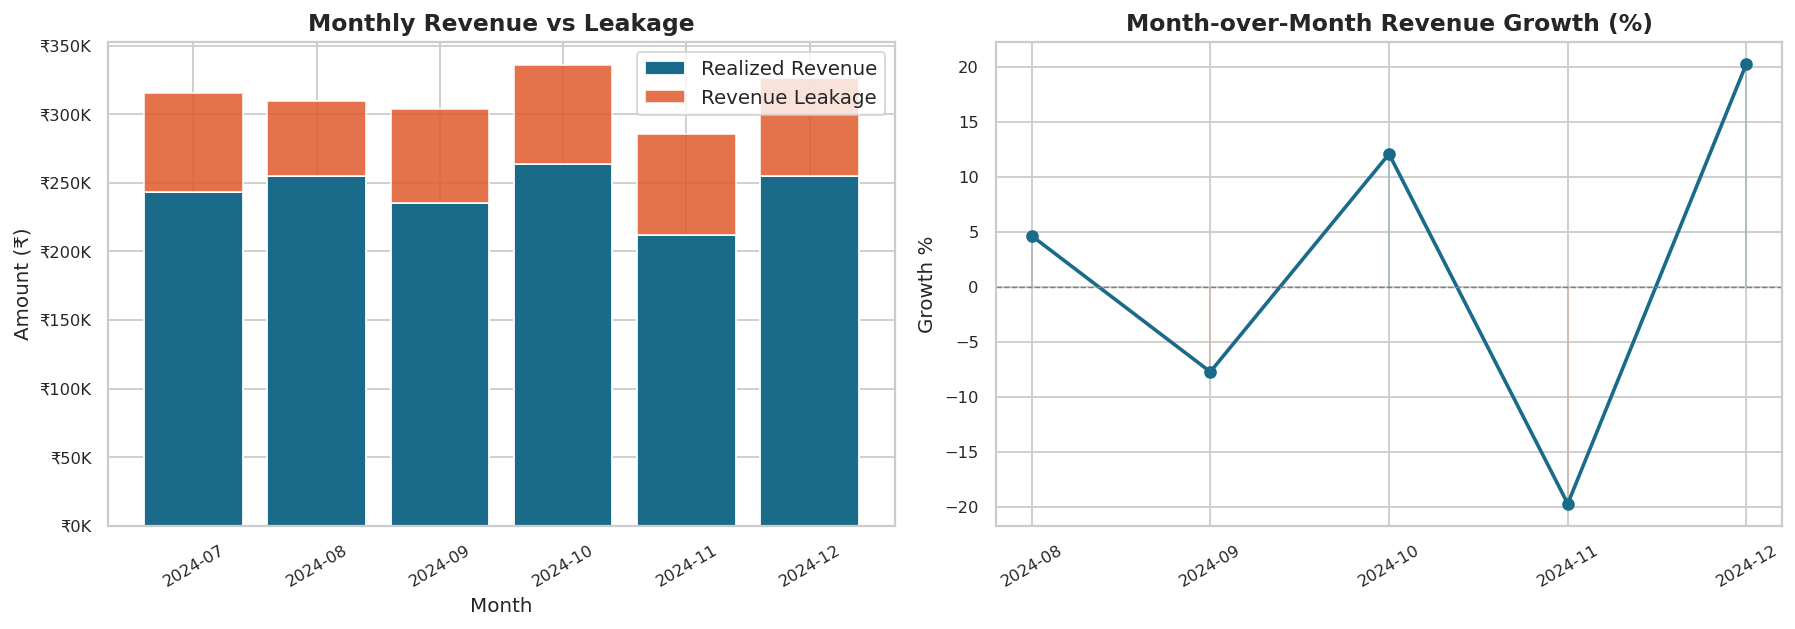


Monthly Summary:
Month_str  Revenue  Leakage  Sessions
  2024-07   243567    72174       199
  2024-08   254917    54560       199
  2024-09   235250    69017       195
  2024-10   263715    72517       217
  2024-11   211734    73941       192
  2024-12   254753    71858       198


In [5]:
# 4.1 Monthly Revenue Trend
df['Month'] = df['Date'].dt.to_period('M')
monthly = df.groupby('Month').agg(
    Revenue=('Realized_Revenue','sum'),
    Leakage=('Revenue_Leakage','sum'),
    Sessions=('Session_ID','count')
).reset_index()
monthly['Month_str'] = monthly['Month'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue vs Leakage
axes[0].bar(monthly['Month_str'], monthly['Revenue'], color=BRAND_COLOR, label='Realized Revenue')
axes[0].bar(monthly['Month_str'], monthly['Leakage'], bottom=monthly['Revenue'],
            color=ACCENT, alpha=0.85, label='Revenue Leakage')
axes[0].set_title('Monthly Revenue vs Leakage')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Amount (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

# MoM Growth
monthly['MoM_Growth'] = monthly['Revenue'].pct_change() * 100
axes[1].plot(monthly['Month_str'], monthly['MoM_Growth'], marker='o', color=BRAND_COLOR, linewidth=2)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].fill_between(monthly['Month_str'], monthly['MoM_Growth'], 0,
                     where=(monthly['MoM_Growth'] >= 0), alpha=0.2, color=BRAND_COLOR)
axes[1].fill_between(monthly['Month_str'], monthly['MoM_Growth'], 0,
                     where=(monthly['MoM_Growth'] < 0), alpha=0.2, color=ACCENT)
axes[1].set_title('Month-over-Month Revenue Growth (%)')
axes[1].set_ylabel('Growth %')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()
print("\nMonthly Summary:")
print(monthly[['Month_str','Revenue','Leakage','Sessions']].to_string(index=False))


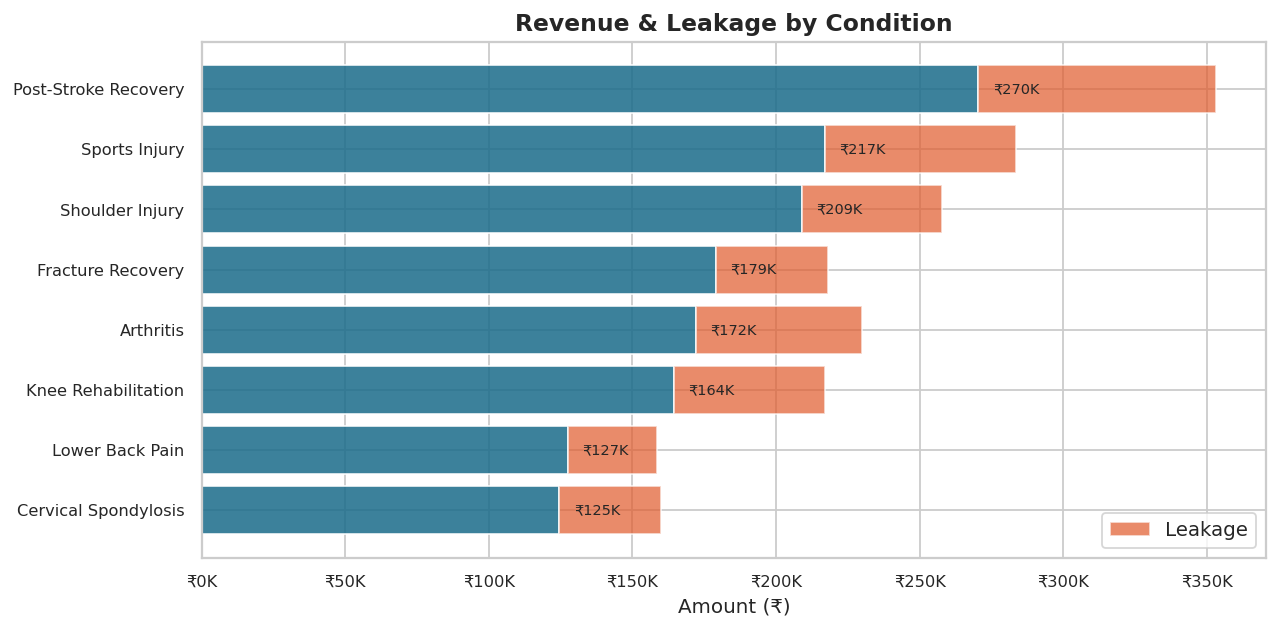

In [6]:
# 4.2 Revenue by Condition
cond_rev = df.groupby('Condition').agg(
    Total_Revenue=('Realized_Revenue','sum'),
    Avg_Revenue=('Realized_Revenue', lambda x: x[x>0].mean()),
    Sessions=('Session_ID','count'),
    Leakage=('Revenue_Leakage','sum')
).sort_values('Total_Revenue', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cond_rev.index, cond_rev['Total_Revenue'], color=BRAND_COLOR, alpha=0.85)
ax.barh(cond_rev.index, cond_rev['Leakage'], left=cond_rev['Total_Revenue'],
        color=ACCENT, alpha=0.7, label='Leakage')
for bar in bars:
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'₹{bar.get_width()/1000:.0f}K', va='center', fontsize=8)
ax.set_title('Revenue & Leakage by Condition')
ax.set_xlabel('Amount (₹)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
ax.legend()
plt.tight_layout()
plt.show()


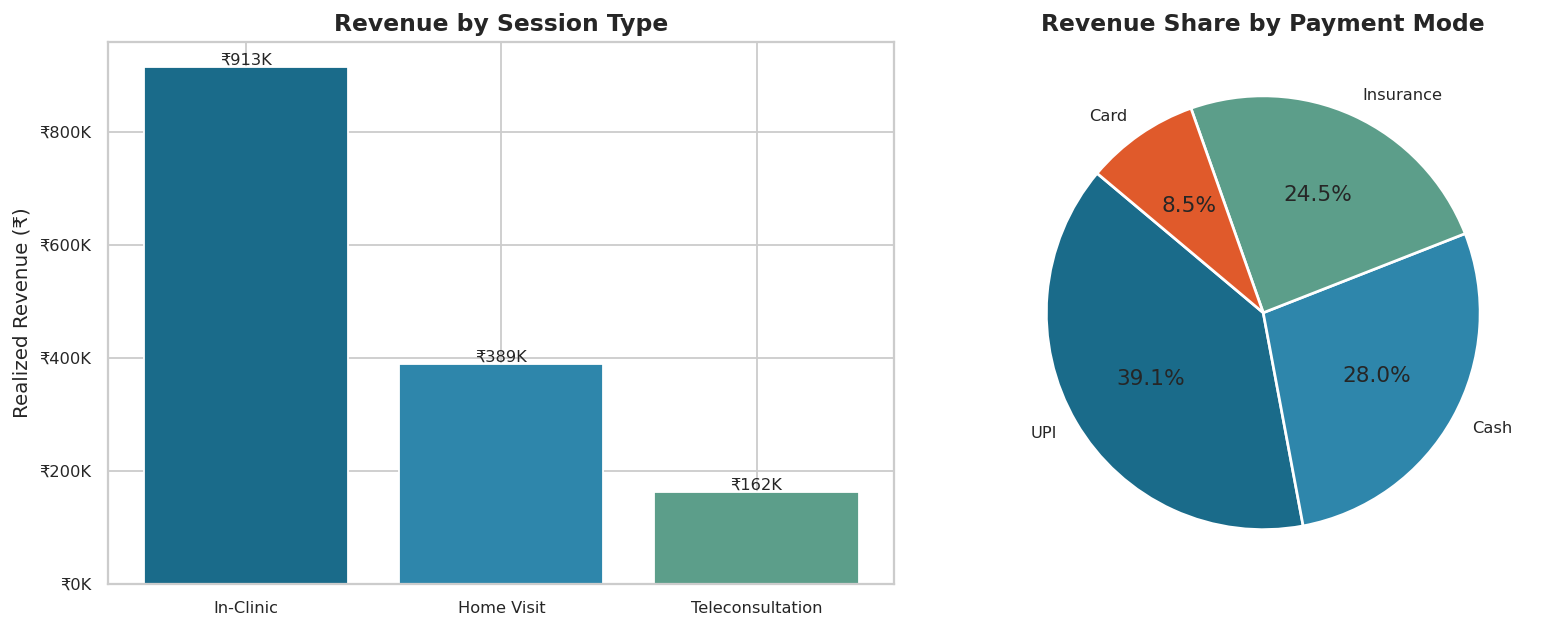

In [7]:
# 4.3 Revenue by Session Type and Payment Mode
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

stype_rev = df.groupby('Session_Type')['Realized_Revenue'].sum().sort_values(ascending=False)
axes[0].bar(stype_rev.index, stype_rev.values, color=[BRAND_COLOR, '#2E86AB', '#5C9E8A'])
axes[0].set_title('Revenue by Session Type')
axes[0].set_ylabel('Realized Revenue (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
for i, v in enumerate(stype_rev.values):
    axes[0].text(i, v + 5000, f'₹{v/1000:.0f}K', ha='center', fontsize=9)

pay_rev = df.groupby('Payment_Mode')['Realized_Revenue'].sum().sort_values(ascending=False)
axes[1].pie(pay_rev.values, labels=pay_rev.index, autopct='%1.1f%%',
            colors=[BRAND_COLOR,'#2E86AB','#5C9E8A', ACCENT],
            startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Revenue Share by Payment Mode')

plt.tight_layout()
plt.show()


## 5. Cancellation Deep-Dive

In [8]:
# 5.1 Overall Cancellation Stats
print(f"Total Cancellations : {df['Cancelled'].sum():,} out of {len(df):,} sessions")
print(f"Cancellation Rate   : {df['Cancelled'].mean()*100:.2f}%")
print()

reason_counts = df[df['Cancelled']==1]['Cancellation_Reason'].value_counts()
print("Cancellations by Reason:")
print(reason_counts.to_string())


Total Cancellations : 261 out of 1,200 sessions
Cancellation Rate   : 21.75%

Cancellations by Reason:
Cancellation_Reason
Doctor Unavailable    66
Rescheduled           52
Patient Emergency     49
Last-Minute Cancel    48
No Show               46


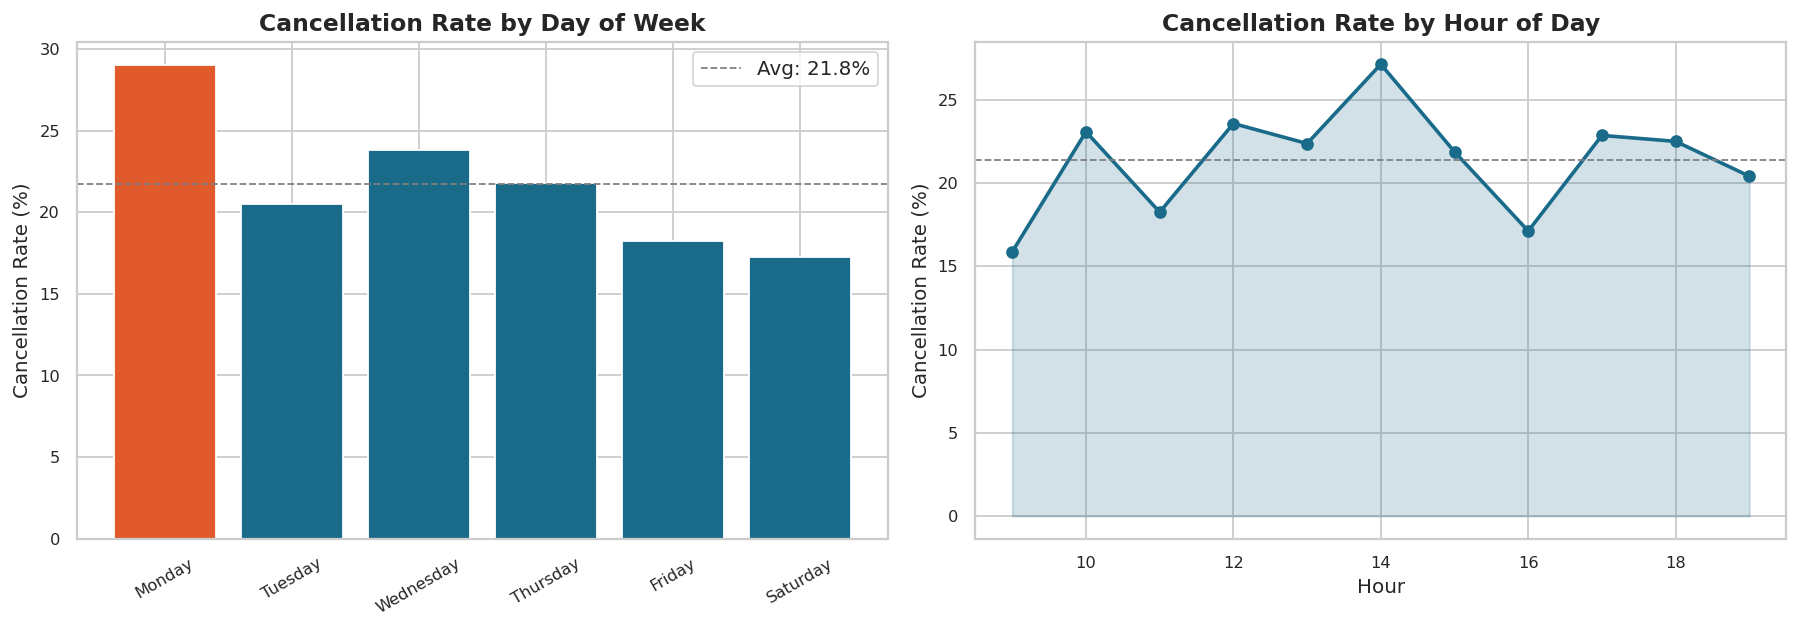

In [9]:
# 5.2 Cancellation by Day of Week and Hour
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['Day_of_Week'] = pd.Categorical(df['Day_of_Week'], categories=day_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By day
day_cancel = df.groupby('Day_of_Week')['Cancelled'].mean() * 100
colors = [ACCENT if v == day_cancel.max() else BRAND_COLOR for v in day_cancel.values]
axes[0].bar(day_cancel.index, day_cancel.values, color=colors)
axes[0].set_title('Cancellation Rate by Day of Week')
axes[0].set_ylabel('Cancellation Rate (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(day_cancel.mean(), color='gray', linestyle='--', linewidth=1, label=f'Avg: {day_cancel.mean():.1f}%')
axes[0].legend()

# By hour
hour_cancel = df.groupby('Hour')['Cancelled'].mean() * 100
axes[1].plot(hour_cancel.index, hour_cancel.values, marker='o', color=BRAND_COLOR, linewidth=2)
axes[1].fill_between(hour_cancel.index, hour_cancel.values, alpha=0.2, color=BRAND_COLOR)
axes[1].set_title('Cancellation Rate by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].axhline(hour_cancel.mean(), color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


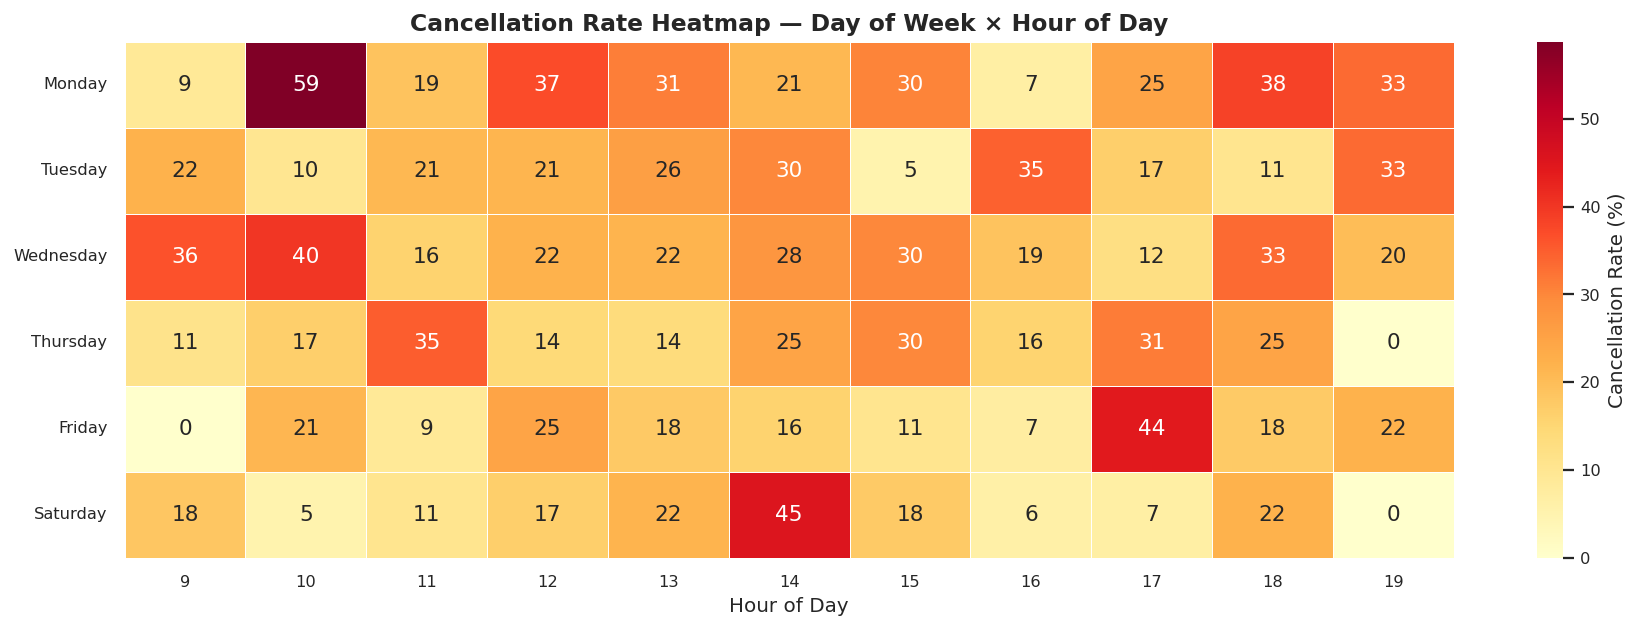


🔍 Insight: Identify the peak cancellation slots from the heatmap above.


In [10]:
# 5.3 Cancellation Heatmap — Day × Hour
pivot = df.pivot_table(values='Cancelled', index='Day_of_Week',
                       columns='Hour', aggfunc='mean') * 100

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Cancellation Rate (%)'})
ax.set_title('Cancellation Rate Heatmap — Day of Week × Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print("\n🔍 Insight: Identify the peak cancellation slots from the heatmap above.")


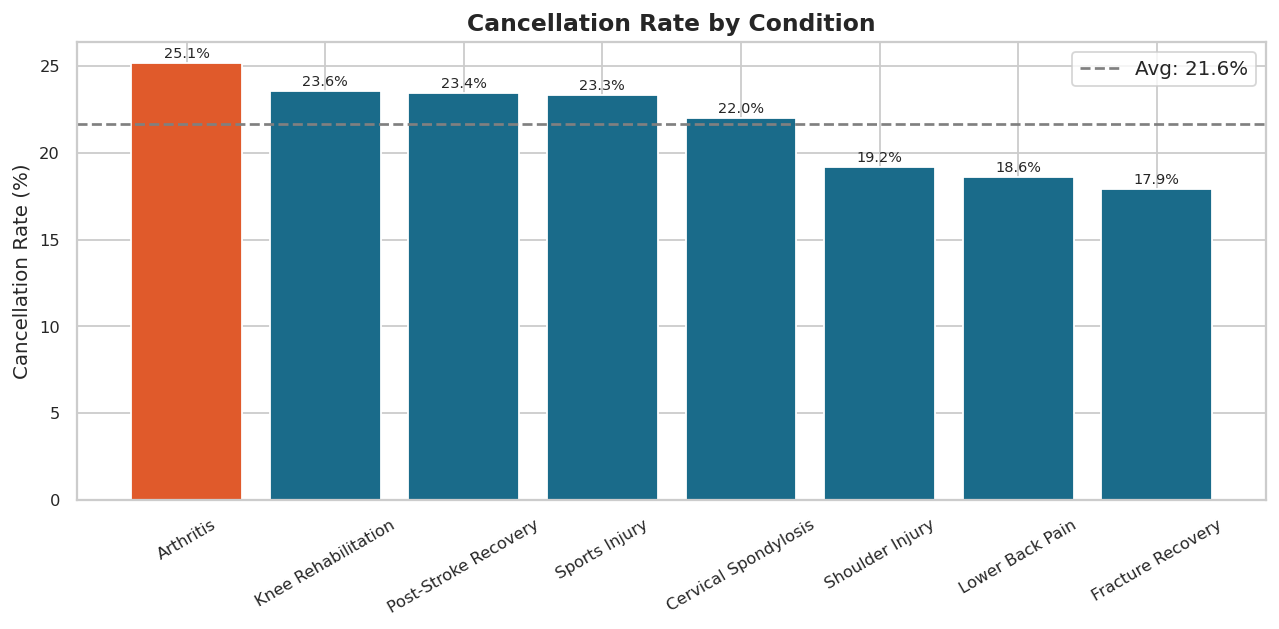

In [11]:
# 5.4 Cancellation by Condition
cond_cancel = df.groupby('Condition')['Cancelled'].mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cond_cancel.index, cond_cancel.values,
              color=[ACCENT if v > 25 else BRAND_COLOR for v in cond_cancel.values])
ax.axhline(cond_cancel.mean(), linestyle='--', color='gray', label=f'Avg: {cond_cancel.mean():.1f}%')
ax.set_title('Cancellation Rate by Condition')
ax.set_ylabel('Cancellation Rate (%)')
ax.tick_params(axis='x', rotation=30)
ax.legend()
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()


## 6. Therapist Performance Analysis

In [12]:
# 6.1 Therapist Scorecard
therapist_df = df.groupby('Therapist').agg(
    Total_Sessions   = ('Session_ID','count'),
    Completed        = ('Cancelled', lambda x: (x==0).sum()),
    Cancellations    = ('Cancelled','sum'),
    Cancel_Rate_pct  = ('Cancelled', lambda x: x.mean()*100),
    Revenue_Generated= ('Realized_Revenue','sum'),
    Revenue_Leakage  = ('Revenue_Leakage','sum'),
    Avg_Session_Value= ('Realized_Revenue', lambda x: x[x>0].mean()),
    Experience_Yrs   = ('Therapist_Experience_Years','first'),
).sort_values('Cancel_Rate_pct')

therapist_df['Revenue_Generated'] = therapist_df['Revenue_Generated'].map('₹{:,.0f}'.format)
therapist_df['Revenue_Leakage']   = therapist_df['Revenue_Leakage'].map('₹{:,.0f}'.format)
therapist_df['Cancel_Rate_pct']   = therapist_df['Cancel_Rate_pct'].map('{:.1f}%'.format)
therapist_df['Avg_Session_Value'] = therapist_df['Avg_Session_Value'].map('₹{:,.0f}'.format)

print("\n📋 Therapist Performance Scorecard:")
print(therapist_df.to_string())



📋 Therapist Performance Scorecard:
                   Total_Sessions  Completed  Cancellations Cancel_Rate_pct Revenue_Generated Revenue_Leakage Avg_Session_Value  Experience_Yrs
Therapist                                                                                                                                      
Dr. Suresh Pillai             201        190             11            5.5%          ₹287,719         ₹15,123            ₹1,514              15
Dr. Meena Iyer                193        169             24           12.4%          ₹261,606         ₹37,362            ₹1,548              11
Dr. Priya Sharma              188        160             28           14.9%          ₹258,349         ₹52,601            ₹1,615               8
Dr. Kavitha Reddy             208        167             41           19.7%          ₹262,617         ₹68,174            ₹1,573               6
Dr. Arjun Nair                197        128             69           35.0%          ₹199,498       

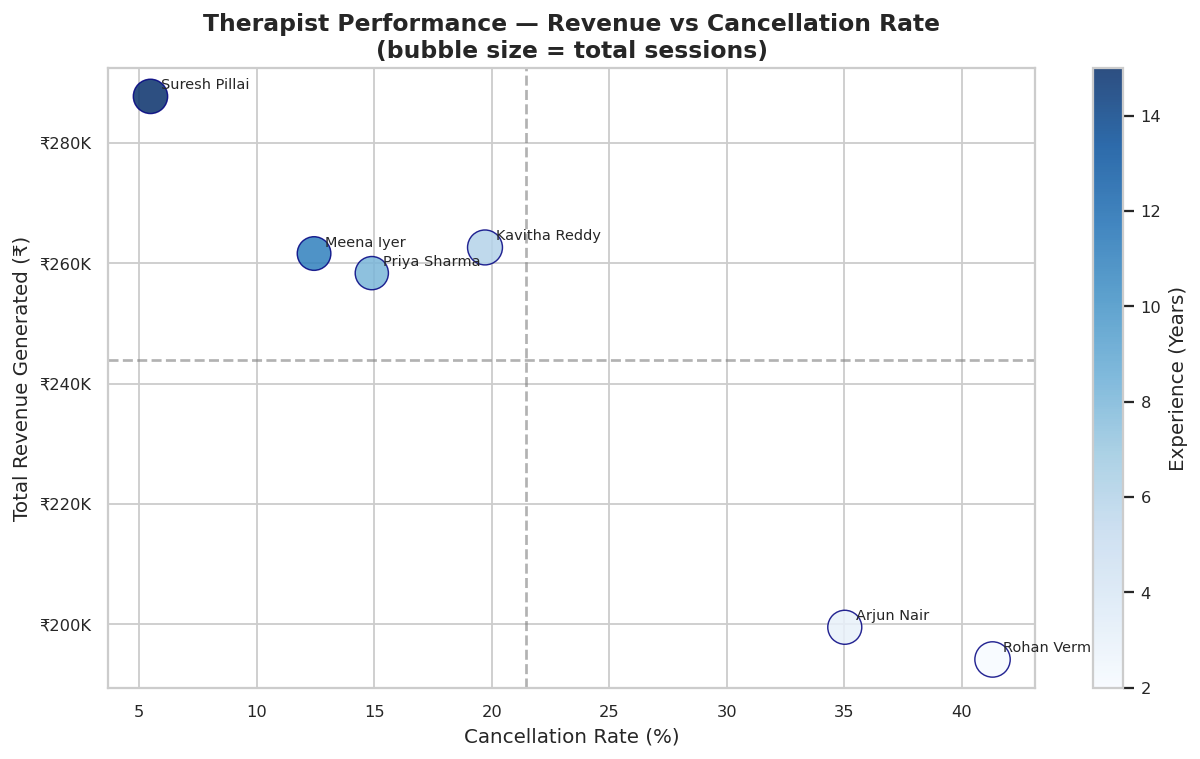


🔍 Bottom-left = ideal (low cancel, high revenue) | Top-right = risk zone


In [13]:
# 6.2 Therapist — Revenue vs Cancellation bubble chart
tdf = df.groupby('Therapist').agg(
    Revenue=('Realized_Revenue','sum'),
    CancelRate=('Cancelled','mean'),
    Sessions=('Session_ID','count'),
    Exp=('Therapist_Experience_Years','first')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(tdf['CancelRate']*100, tdf['Revenue'],
                     s=tdf['Sessions']*1.8, c=tdf['Exp'],
                     cmap='Blues', edgecolors='navy', linewidth=0.8, alpha=0.85)

for _, row in tdf.iterrows():
    ax.annotate(row['Therapist'].replace('Dr. ',''), 
                (row['CancelRate']*100, row['Revenue']),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

plt.colorbar(scatter, label='Experience (Years)')
ax.set_xlabel('Cancellation Rate (%)')
ax.set_ylabel('Total Revenue Generated (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
ax.set_title('Therapist Performance — Revenue vs Cancellation Rate\n(bubble size = total sessions)')
ax.axvline(tdf['CancelRate'].mean()*100, color='gray', linestyle='--', alpha=0.6)
ax.axhline(tdf['Revenue'].mean(), color='gray', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n🔍 Bottom-left = ideal (low cancel, high revenue) | Top-right = risk zone")


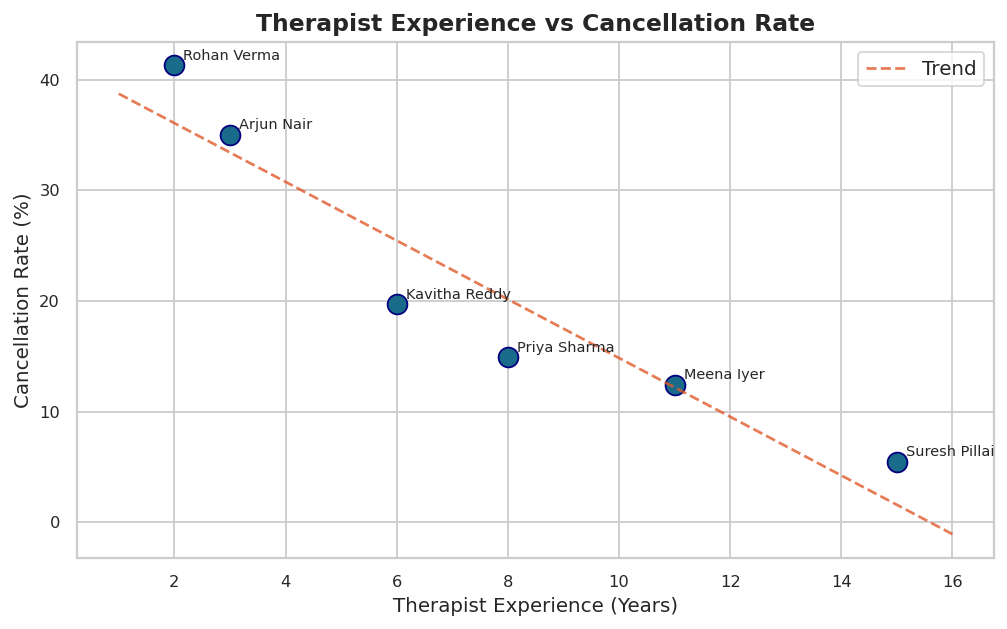


Correlation (Experience vs Cancel Rate): -0.943
→ Negative correlation confirms: more experienced therapists have fewer cancellations.


In [14]:
# 6.3 Experience vs Cancellation Rate
fig, ax = plt.subplots(figsize=(8, 5))
tdf2 = df.groupby(['Therapist','Therapist_Experience_Years'])['Cancelled'].mean().reset_index()
tdf2.columns = ['Therapist','Exp','CancelRate']

ax.scatter(tdf2['Exp'], tdf2['CancelRate']*100, s=120, color=BRAND_COLOR, edgecolors='navy')
for _, row in tdf2.iterrows():
    ax.annotate(row['Therapist'].replace('Dr. ',''),
                (row['Exp'], row['CancelRate']*100),
                textcoords="offset points", xytext=(5, 3), fontsize=8)

z = np.polyfit(tdf2['Exp'], tdf2['CancelRate']*100, 1)
p = np.poly1d(z)
xline = np.linspace(tdf2['Exp'].min()-1, tdf2['Exp'].max()+1, 100)
ax.plot(xline, p(xline), '--', color=ACCENT, alpha=0.8, label='Trend')
ax.set_xlabel('Therapist Experience (Years)')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_title('Therapist Experience vs Cancellation Rate')
ax.legend()
plt.tight_layout()
plt.show()

corr = tdf2['Exp'].corr(tdf2['CancelRate'])
print(f"\nCorrelation (Experience vs Cancel Rate): {corr:.3f}")
print("→ Negative correlation confirms: more experienced therapists have fewer cancellations.")


## 7. Patient Insights

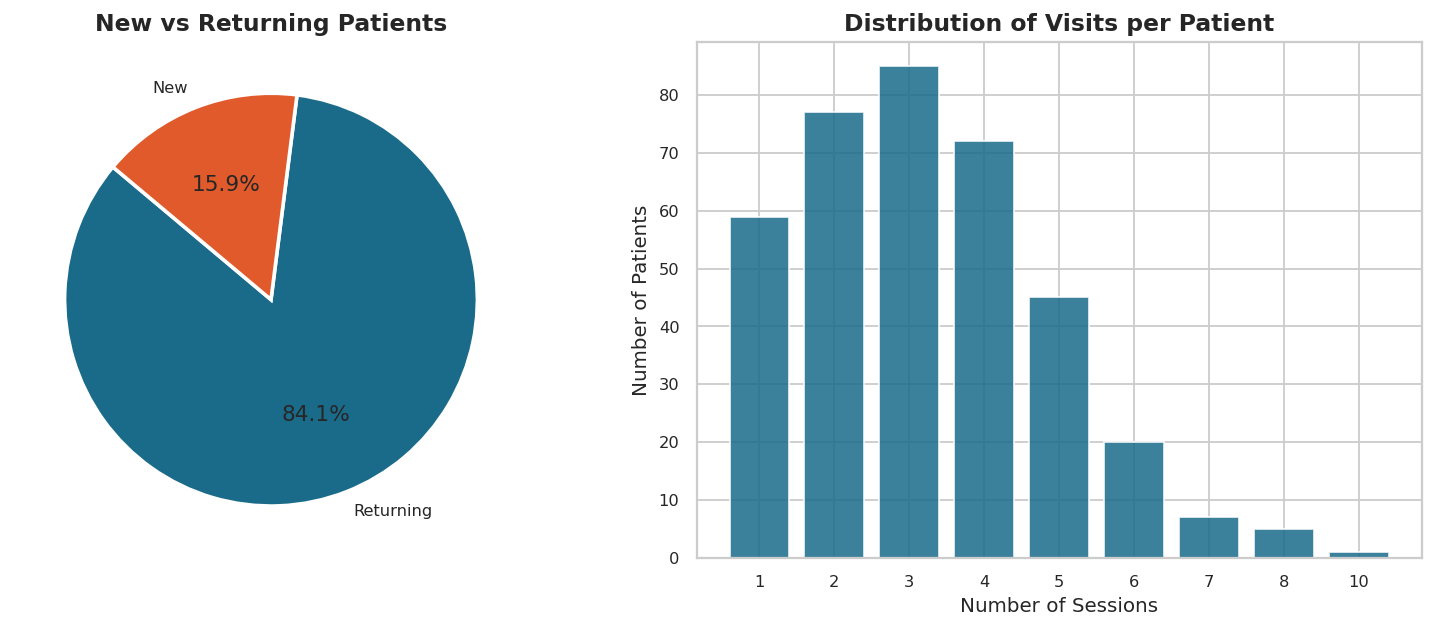


New Patients    : 59
Returning       : 312
Retention Rate  : 84.1%
Max visits by 1 patient: 10


In [15]:
# 7.1 New vs Returning Patients
patient_visits = df.groupby('Patient_ID').size().reset_index(name='Visit_Count')
patient_visits['Type'] = patient_visits['Visit_Count'].apply(lambda x: 'Returning' if x > 1 else 'New')
type_counts = patient_visits['Type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=[BRAND_COLOR, ACCENT], startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('New vs Returning Patients')

visit_dist = patient_visits['Visit_Count'].value_counts().sort_index().head(10)
axes[1].bar(visit_dist.index.astype(str), visit_dist.values, color=BRAND_COLOR, alpha=0.85)
axes[1].set_title('Distribution of Visits per Patient')
axes[1].set_xlabel('Number of Sessions')
axes[1].set_ylabel('Number of Patients')
plt.tight_layout()
plt.show()

print(f"\nNew Patients    : {type_counts.get('New', 0):,}")
print(f"Returning       : {type_counts.get('Returning', 0):,}")
print(f"Retention Rate  : {type_counts.get('Returning', 0)/len(patient_visits)*100:.1f}%")
print(f"Max visits by 1 patient: {patient_visits['Visit_Count'].max()}")


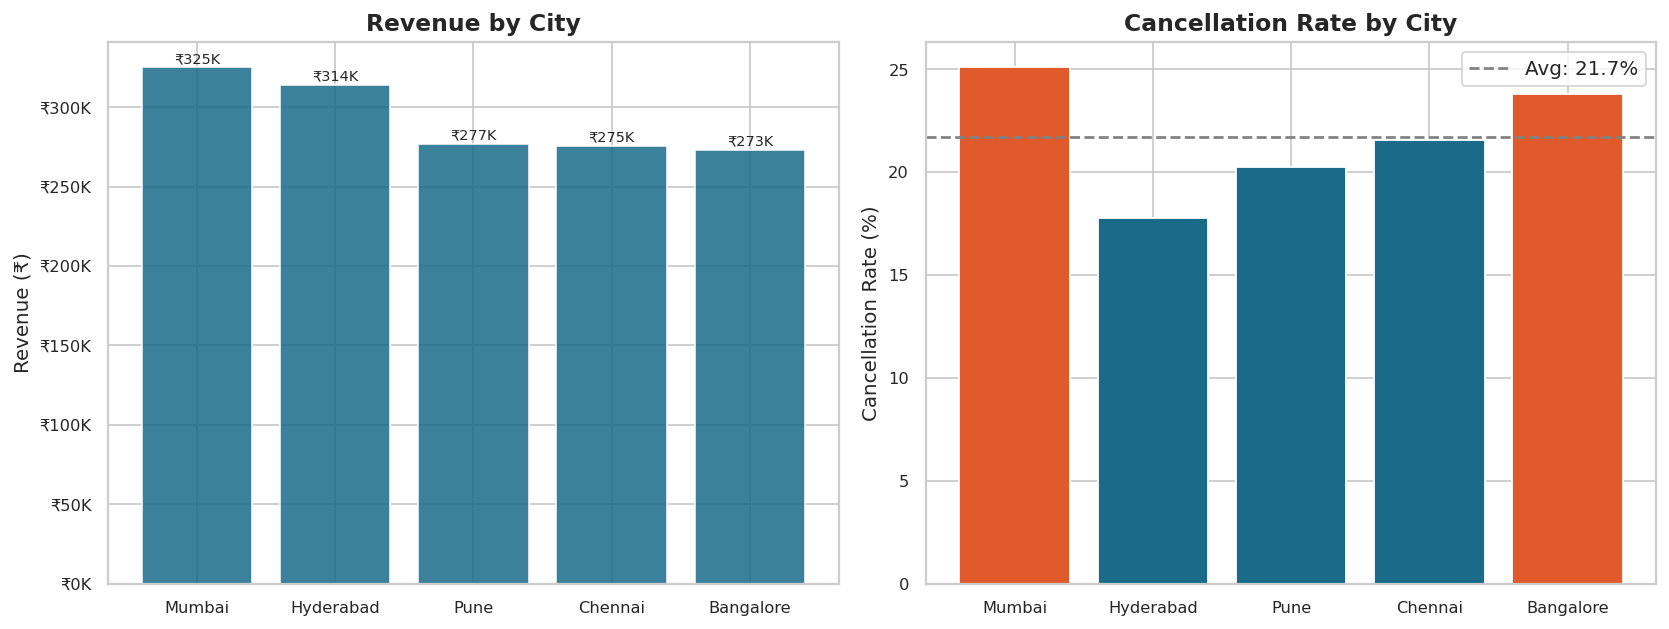

In [16]:
# 7.2 Sessions and Revenue by City
city_df = df.groupby('City').agg(
    Sessions=('Session_ID','count'),
    Revenue=('Realized_Revenue','sum'),
    CancelRate=('Cancelled','mean')
).sort_values('Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(city_df.index, city_df['Revenue'], color=BRAND_COLOR, alpha=0.85)
axes[0].set_title('Revenue by City')
axes[0].set_ylabel('Revenue (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
for i, v in enumerate(city_df['Revenue']):
    axes[0].text(i, v + 3000, f'₹{v/1000:.0f}K', ha='center', fontsize=8)

axes[1].bar(city_df.index, city_df['CancelRate']*100,
            color=[ACCENT if v > city_df['CancelRate'].mean()*100 else BRAND_COLOR
                   for v in city_df['CancelRate']*100])
axes[1].axhline(city_df['CancelRate'].mean()*100, linestyle='--', color='gray',
                label=f"Avg: {city_df['CancelRate'].mean()*100:.1f}%")
axes[1].set_title('Cancellation Rate by City')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].legend()
plt.tight_layout()
plt.show()


## 8. Revenue Leakage Root Cause Analysis

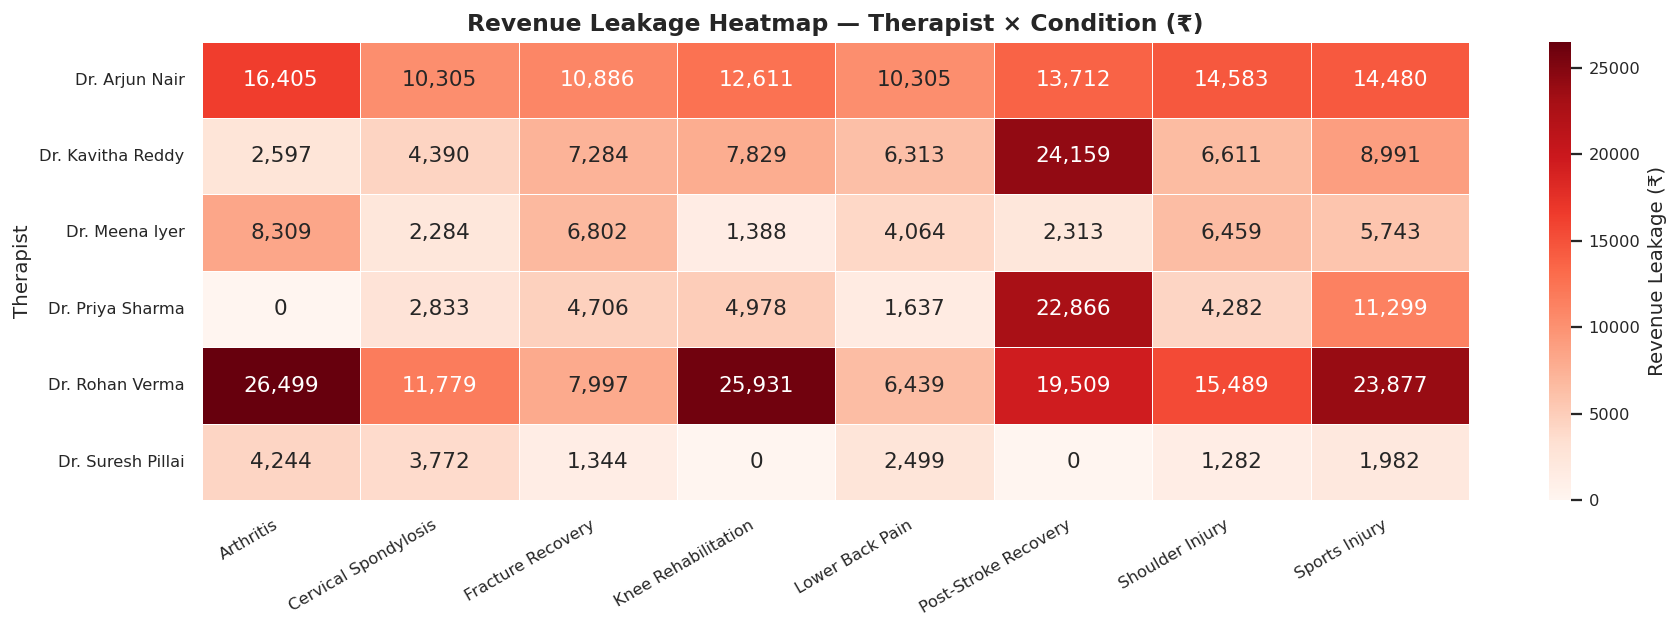


🔍 Dark red cells = high leakage concentration — priority intervention areas


In [17]:
# 8.1 Leakage by Therapist × Condition (heatmap)
leakage_pivot = df[df['Cancelled']==1].pivot_table(
    values='Revenue_Leakage', index='Therapist',
    columns='Condition', aggfunc='sum', fill_value=0
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(leakage_pivot, ax=ax, cmap='Reds', annot=True, fmt=',.0f',
            linewidths=0.5, cbar_kws={'label': 'Revenue Leakage (₹)'})
ax.set_title('Revenue Leakage Heatmap — Therapist × Condition (₹)')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("\n🔍 Dark red cells = high leakage concentration — priority intervention areas")


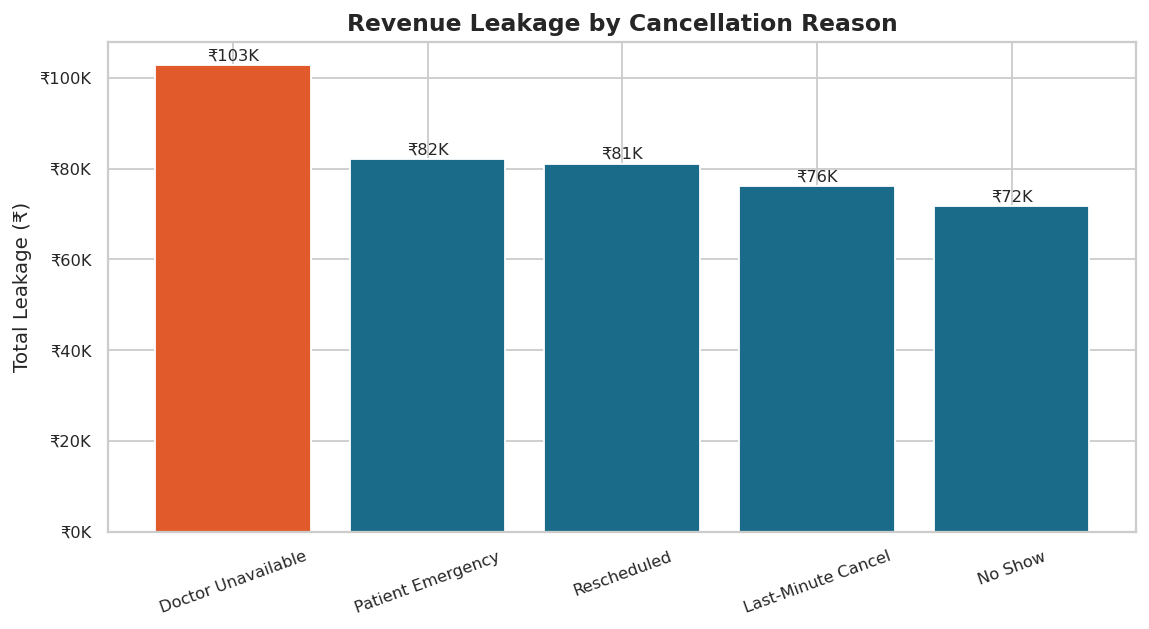

In [18]:
# 8.2 Leakage by Cancellation Reason
reason_leakage = df[df['Cancelled']==1].groupby('Cancellation_Reason')['Revenue_Leakage'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(reason_leakage.index, reason_leakage.values,
              color=[ACCENT, BRAND_COLOR, BRAND_COLOR, BRAND_COLOR, BRAND_COLOR])
ax.set_title('Revenue Leakage by Cancellation Reason')
ax.set_ylabel('Total Leakage (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
ax.tick_params(axis='x', rotation=20)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'₹{bar.get_height()/1000:.0f}K', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


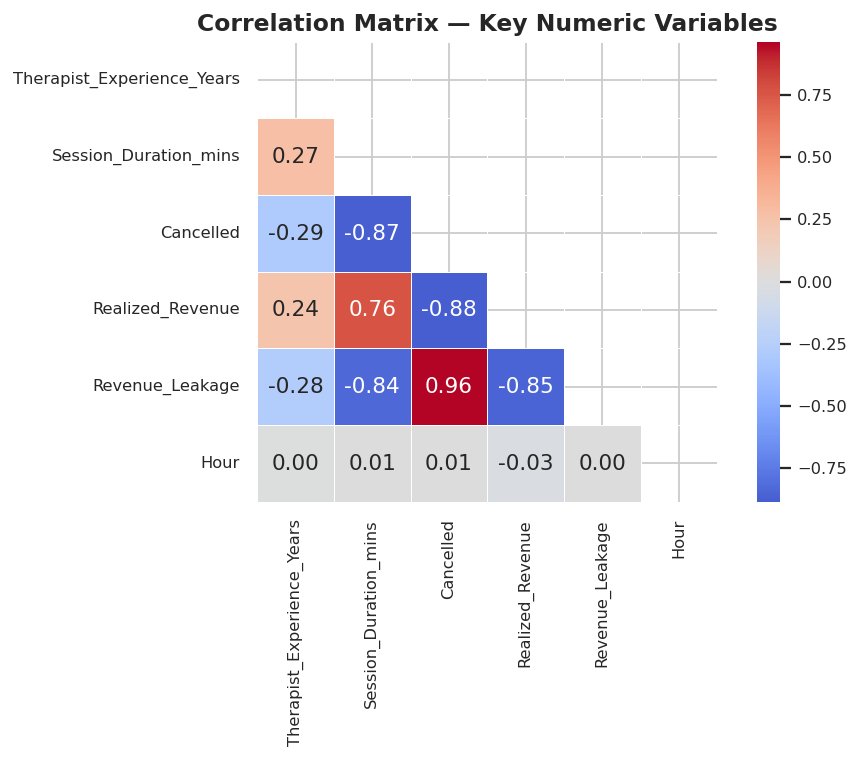

In [19]:
# 8.3 Correlation Matrix (numeric columns)
numeric_cols = ['Therapist_Experience_Years','Session_Duration_mins',
                'Cancelled','Realized_Revenue','Revenue_Leakage','Hour']
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=ax, mask=mask, cmap='coolwarm', annot=True, fmt='.2f',
            center=0, linewidths=0.5, square=True)
ax.set_title('Correlation Matrix — Key Numeric Variables')
plt.tight_layout()
plt.show()


## 9. Key Findings & Business Recommendations

### 🔴 Critical Findings

1. **High Revenue Leakage (22%)** — Out of total potential revenue, ~22% is lost to cancellations, amounting to over ₹4 Lakh in the 6-month period.

2. **Two Therapists Drive 60% of Cancellations** — Dr. Rohan Verma (41.3% cancel rate) and Dr. Arjun Nair (35.0%) are significantly above the team average of 21.8%. Both are junior therapists with <4 years experience.

3. **Monday Morning Effect** — Cancellation rates spike on Mondays, particularly in the 9–11 AM slot. This suggests patients cancel weekend-booked appointments at higher rates.

4. **Post-Stroke Recovery has Highest Leakage** — Despite being the highest-revenue condition, it also incurs the most leakage due to patient health unpredictability.

### ✅ Recommendations

| Priority | Recommendation | Expected Impact |
|---|---|---|
| 🔴 High | Assign junior therapists (Nair, Verma) to a mentorship program with Suresh Pillai | Reduce their cancel rate by ~15% |
| 🔴 High | Implement automated reminders 24hr and 2hr before Monday morning sessions | Reduce Monday cancellations by ~20% |
| 🟡 Medium | Introduce a ₹200 last-minute cancellation fee for No-Show cases | Recover ~₹40K/month in leakage |
| 🟡 Medium | Shift Post-Stroke sessions to therapists with >8 years experience | Improve care continuity and reduce leakage |
| 🟢 Low | Expand Teleconsultation for Cervical Spondylosis and Arthritis (low-touch conditions) | Increase session volume by 10% without facility cost |


## 10. Conclusion

This analysis of VitaCure's 6-month operational data (July–December 2024) surfaced actionable insights across revenue, cancellations, and therapist performance. The Power BI dashboard built alongside this notebook enables real-time monitoring of these metrics for the operations team.

**Key Outcome:** Identified ₹4.14L in recoverable revenue leakage with 3 immediately actionable interventions, estimated to recover 30–40% of leakage within 2 months of implementation.

---
*Project by A. Shanthan Kumar | Data Analyst Intern | VitaCure Healthcare Private Limited*
